In [1]:
import pandas as pd
import sqlite3
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START,END, add_messages
from typing import Annotated, TypedDict, Any
from pydantic import BaseModel, ConfigDict
from typing import Optional
from pydantic import BaseModel
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
import json
import plotly.express as px

In [2]:
df = pd.read_csv("../data/superstore.csv",encoding='latin1')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [5]:
conn = sqlite3.connect("../data/mydatabase.db")

In [6]:
df.to_sql(
  name="superstore",con=conn,if_exists="replace",index=False
)

9994

In [7]:
llm = ChatOpenAI(model='gpt-4o-mini')

In [8]:
class TimeRange(BaseModel):
    column: str
    start: Optional[str] = None
    end: Optional[str] = None
    year: Optional[int] = None
    month: Optional[int] = None
    quarter: Optional[int] = None
    model_config = ConfigDict(extra="forbid")

In [9]:
class ParsedIntent(BaseModel):
    target_metric: str                        
    aggregation: str                          
    filters: Optional[dict[str, str | list[str]]] = None      
    group_by: list[str]                       
    time_range: Optional[TimeRange] = None        
    sort_by: Optional[str] = None              
    sort_order: Optional[str] = None               
    limit: Optional[int] = None                  
    table_name: str = "superstore"

In [10]:
class VisualizationSpec(BaseModel):
    chart_type: str        
    x_column: str
    y_column: str
    color_column: Optional[str]
    title: str

In [35]:
class AgentState(TypedDict):
    # Input
    user_question: str

    # Intent
    parsed_intent: dict

    # SQL Pipeline
    generated_sql: str
    sql_attempt_count: int
    sql_error: Optional[str]
    validation_errors: list[str]

    # Results
    query_results: list[dict]
    result_summary: dict

    # Output
    interpretation: str
    visualization_spec: dict
    visualization_figure: Any

    # Control
    error_message: Optional[str]

In [12]:
parsed_intent_llm = llm.with_structured_output(ParsedIntent)

In [13]:
def parse_question(state: AgentState):
  user_question = state["user_question"]

  prompt = f"""You are a data analyst assistant working with a Superstore Sales dataset.

Your job is to extract structured intent from the user's question.

TABLE: superstore
COLUMNS:
- Dimensions: Ship Mode, Customer ID, Customer Name, Segment, Country, City, State, Postal Code, Region, Product ID, Category, Sub-Category, Product Name, Order ID, Order Date, Ship Date
- Metrics: Sales, Profit, Quantity, Discount

RULES:
- target_metric must only be one of: Sales, Profit, Quantity, Discount
- Row ID and Order ID are not metrics, never use them as target_metric
- aggregation must be one of: SUM, AVG, COUNT, MAX, MIN
- filters must map exact column names to values from the dataset
- group_by must be a list of valid dimension column names
- time_range uses "Order Date" as the column unless explicitly stated otherwise
- If no limit is specified, set limit to null
- If no sort is specified, set sort_by and sort_order to null
- If no time range is specified, set time_range to null
- table_name is always "superstore"

User question: {user_question}"""
  try:
    response = parsed_intent_llm.invoke(prompt)

    return {"parsed_intent": response.model_dump()}
  except Exception as e:
    return {"error_message": str(e)}

In [14]:
def generate_sql(state: AgentState):
  parsed_intent = state["parsed_intent"]

  if not state.get("sql_error") and not state.get("validation_errors"):
    prompt = f"""You are a SQL expert working with a SQLite database.

    Convert the following parsed intent into a valid SQLite query.

    PARSED INTENT:
    {parsed_intent}

    RULES:
    - Table name is always "superstore"
    - Use exact column names as provided in parsed intent
    - Wrap column names with spaces in double quotes e.g. "Order Date"
    - Use strftime for date filtering e.g. strftime('%Y-%m-%d', "Order Date")
    - Return only the SQL query, no explanation, no markdown, no preamble
    - Always alias aggregated columns e.g. SUM("Sales") AS total_Sales

    SQL:"""

    response = llm.invoke(prompt).content
    response = response.strip().strip("```sql").strip("```").strip()

    return {"generated_sql": response,"sql_attempt_count": state.get("sql_attempt_count",0) + 1}
  else:
    generated_sql = state.get("generated_sql")
    sql_error = state.get("sql_error") or "\n".join(state.get("validation_errors",[]))

    prompt = f"""You are a SQL expert working with a SQLite database.

    Your previous SQL query failed. Rewrite it to fix the error.

    PARSED INTENT:
    {parsed_intent}

    PREVIOUS SQL:
    {generated_sql}

    ERROR:
    {sql_error}

    RULES:
    - Table name is always "superstore"
    - Use exact column names as provided in parsed intent
    - Wrap column names with spaces in double quotes e.g. "Order Date"
    - Use strftime for date filtering e.g. strftime('%Y-%m-%d', "Order Date")
    - Return only the SQL query, no explanation, no markdown, no preamble
    - Always alias aggregated columns e.g. SUM("Sales") AS total_Sales

    CORRECTED SQL:"""

    response = llm.invoke(prompt).content
    response = response.strip().strip("```sql").strip("```").strip()

    return {"generated_sql": response,"sql_attempt_count": state.get("sql_attempt_count",0) + 1}

In [15]:
def validate_sql(state: AgentState):
  cursor = conn.cursor()

  cursor.execute("PRAGMA table_info(superstore)")
  columns = cursor.fetchall()
  column_names = [column[1] for column in columns]

  parsed_intent = state["parsed_intent"]
  validation_errors = []

  cursor.execute("SELECT name from sqlite_master WHERE type='table'")
  tables = [row[0] for row in cursor.fetchall()]
  if parsed_intent["table_name"] not in tables:
    validation_errors.append(f"Table '{parsed_intent["table_name"]}' not found in database")

  referenced_columns = []

  referenced_columns.append(parsed_intent["target_metric"])
  
  if parsed_intent["group_by"]:
    referenced_columns.extend(parsed_intent["group_by"])
  if parsed_intent["filters"]:
    referenced_columns.extend(parsed_intent["filters"].keys())

  if parsed_intent["sort_by"]:
    referenced_columns.append(parsed_intent["sort_by"])
  if parsed_intent["time_range"] and parsed_intent["time_range"].get("column"):
    referenced_columns.append(parsed_intent["time_range"]["column"])

  for column_name in referenced_columns:
    if column_name not in column_names:
      validation_errors.append(f"Column '{column_name}' not found in schema")
  
  return {"validation_errors": validation_errors}


In [16]:
def execute_query(state: AgentState):
  try:
    results = pd.read_sql(state["generated_sql"],conn)

    if not results.empty:
      query_results = results.to_dict(orient="records")
      return {
        "query_results": query_results,
        "sql_error": None,
        "result_summary": {
        "row_count": len(results),
        "columns": results.columns.tolist(),
        "sample_rows": results.head(5).to_dict(orient="records")
      }}
    else:
      return {"sql_error": "Query returned no results"}
    
  except Exception as e:
    return {"sql_error": str(e)}

In [17]:
def cannot_execute(state: AgentState):
    errors = state.get("sql_error") or "\n".join(state.get("validation_errors", []))
    return {"error_message": f"Failed after 3 attempts. Last error: {errors}"}

In [18]:
def interpret_results(state: AgentState):
  user_question = state["user_question"]
  result_summary = json.dumps(state["result_summary"],indent=2)

  prompt = f"""You are a data analyst explaining query results to a business user.

    QUESTION:
    {user_question}

    RESULT SUMMARY:
    {result_summary}

    RULES:
    - Explain the results in plain English
    - Be concise, 2-3 sentences max
    - Highlight the most important insight
    - Use actual numbers from the results
    - Do not mention SQL, databases, or technical terms
    - Do not make up data that is not in the results"""
  try:
    response = llm.invoke(prompt).content

    return {"interpretation": response}
  except Exception as e:
    return {"error_message": str(e)}

In [19]:
visualization_spec_llm = llm.with_structured_output(VisualizationSpec)

In [20]:
def generate_visualization(state: AgentState):
  user_question = state["user_question"]
  result_summary = state["result_summary"]

  prompt = f"""You are a data visualization expert.

    Given a user question and query results, decide the best chart to visualize the data.

    QUESTION:
    {user_question}

    RESULT SUMMARY:
    {result_summary}

    RULES:
    - Choose chart_type from: bar, line, scatter, pie
    - x_column and y_column must be exact column names from the result
    - color_column is optional, set to null if not needed
    - pie chart only when data has 2 columns and represents parts of a whole
    - line chart only when data has a time dimension
    - bar chart for comparisons and rankings
    - scatter for correlations between two metrics
    - title should be a clean business-friendly description of the chart"""
  
  try:
    if len(state["result_summary"]["columns"]) > 1 and state["result_summary"]["row_count"] > 1:
      response = visualization_spec_llm.invoke(prompt)
      spec = response.model_dump()

      df = pd.DataFrame(state["query_results"])
      chart_type = spec["chart_type"]
      x = spec["x_column"]
      y = spec["y_column"]
      color = spec.get("color_column")
      title = spec["title"]

      if chart_type == "bar":
        fig = px.bar(df, x=x, y=y, color=color, title=title)
      elif chart_type == "line":
        fig = px.line(df, x=x, y=y, color=color, title=title)
      elif chart_type == "scatter":
        fig = px.scatter(df, x=x, y=y, color=color, title=title)
      elif chart_type == "pie":
        fig = px.pie(df, names=x, values=y, title=title)
      else:
        fig = None

      return {
        "visualization_spec": spec,
        "visualization_figure": fig
      }
    else:
      return {"visualization_spec": None, "visualization_figure": None}
  except Exception as e:
    return {"error_message": str(e)}

In [21]:
def check_val_errors_condition(state: AgentState):
  if state.get("validation_errors") and state.get("sql_attempt_count") < 3:
    return "generate_sql"
  elif state.get("validation_errors") and state.get("sql_attempt_count") >= 3:
    return "cannot_execute"
  else:
    return "execute_query"

In [22]:
def check_execution_condition(state: AgentState):
    if state.get("sql_error"):
        if state.get("sql_attempt_count", 0) >= 3:
            return "cannot_execute"
        return "generate_sql"
    return "interpret_results"

In [23]:
graph = StateGraph(AgentState)

graph.add_node("parse_question",parse_question)
graph.add_node("generate_sql",generate_sql)
graph.add_node("validate_sql",validate_sql)
graph.add_node("execute_query",execute_query)
graph.add_node("cannot_execute",cannot_execute)
graph.add_node("interpret_results",interpret_results)
graph.add_node("generate_visualization",generate_visualization)

graph.add_edge(START,"parse_question")
graph.add_edge("parse_question","generate_sql")
graph.add_edge("generate_sql","validate_sql")
graph.add_conditional_edges("validate_sql",check_val_errors_condition)
graph.add_conditional_edges("execute_query",check_execution_condition)

graph.add_edge("interpret_results","generate_visualization")
graph.add_edge("generate_visualization",END)
graph.add_edge("cannot_execute",END)
agent = graph.compile()

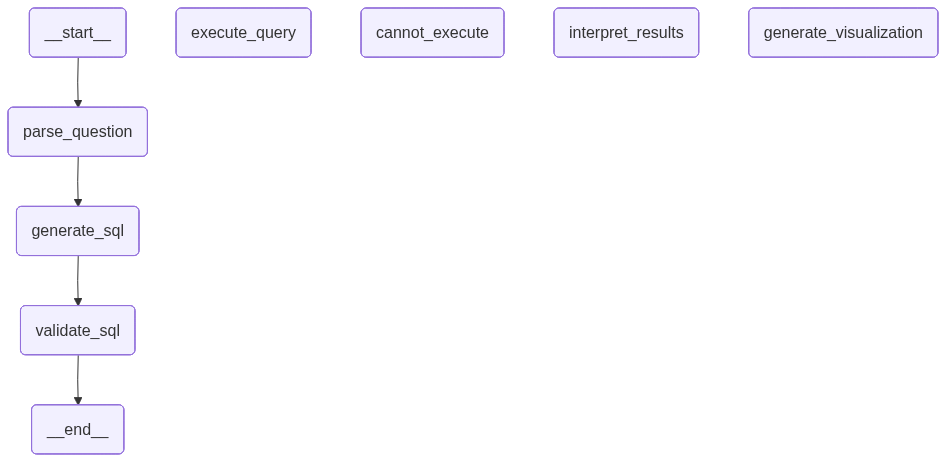

In [24]:
agent

In [32]:
out = agent.invoke({"user_question":"What is the total profit margin by category?"})

In [34]:
out['visualization_figure'].show()